In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data final project.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
print(df.shape)

(301355, 5)


Проверяем формат столбцов

In [4]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

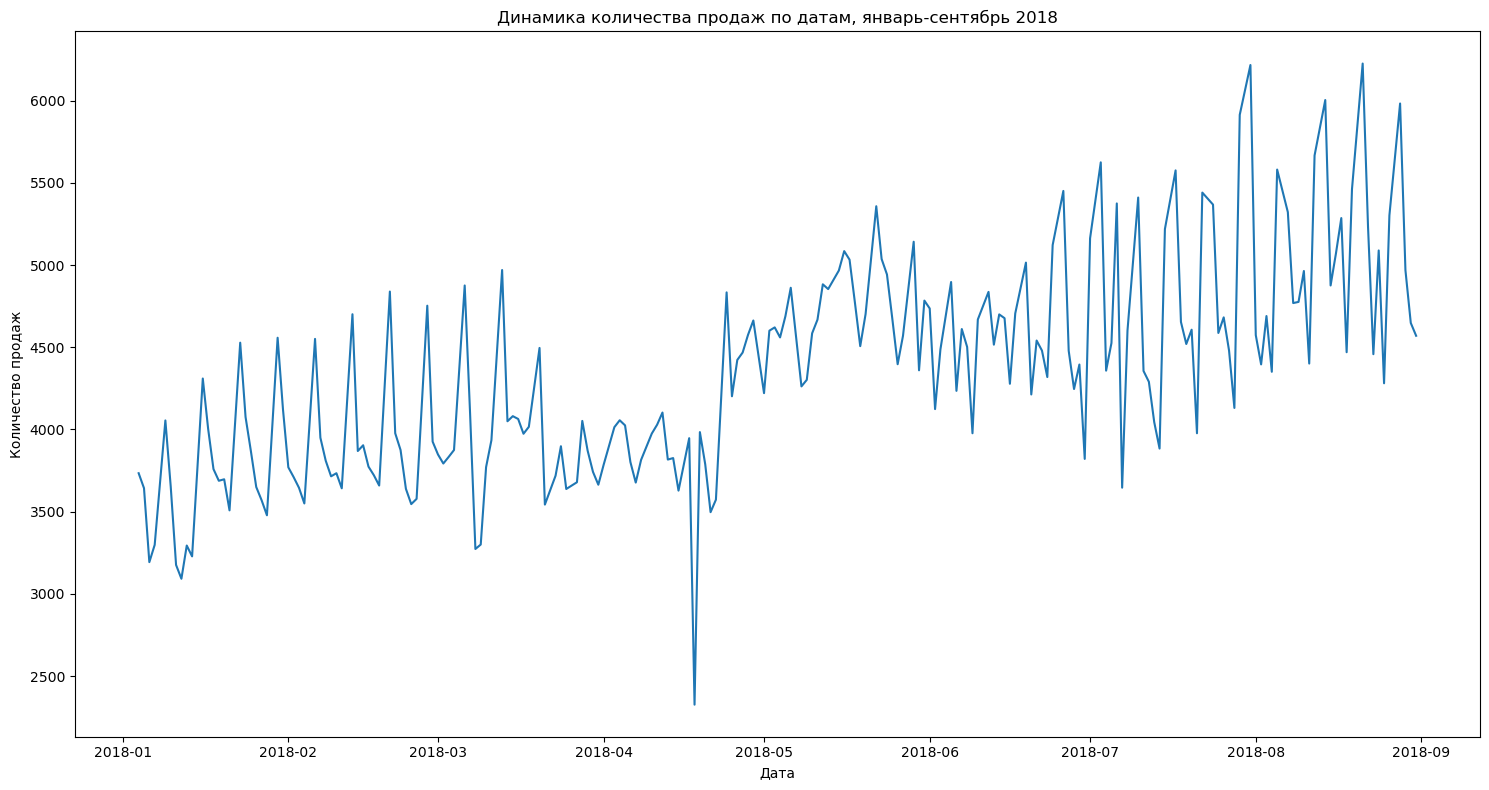

In [63]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='Дата', y='Количество продаж', data=grouped_df)
plt.title('Динамика количества продаж по датам, январь-сентябрь 2018')
plt.ylabel('Количество продаж')
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Как видно из графика, продажи сильно колеблются от дня ко дню. Основная масса значений находится между 3100 и 5500.
Такие отчетливые пики могут говорить о цикличной еженедельной природе спроса на товар.
При этом также можно отметить стабильный плавный восходящий тренд от января к сентябрю. Так, наиболее высокий уровень продаж достигался летом, в эти месяцы пики продаж превышают 6000. Также летом увеличивается амплитуда / высота пиков. Кроме того, можно отметить резкий спад, произошедший в апреле. Возможно, в этот период произошло что-то, что повлекло за собой временное падение спроса на товар. Это аномалия, которая не укладывается в общую динамику.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
q1 = df['Количество'].quantile(0.25)
q3 = df['Количество'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5 * iqr
outliers = df[df['Количество'] > ul]
max_outlier = outliers.loc[outliers['Количество'].idxmax()]
max_outlier

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [19]:
wednesdays_summer_w3 = df[(df['Склад'] == 3) & (df['Дата'] >= '2018-06-01') & (df['Дата'] <= '2018-08-31') & (df['Дата'].dt.weekday == 2)]
wednesdays_summer_w3_grouped = wednesdays_summer_w3.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).reset_index()
top_product = wednesdays_summer_w3_grouped.loc[wednesdays_summer_w3_grouped['Количество'].idxmax()]
top_product 

Номенклатура    product_1
Количество           2267
Name: 0, dtype: object

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [37]:
temperatures = pd.read_csv('temperatures.csv')
temperatures['Date'] = pd.to_datetime(temperatures['Date'])
avg_temperatures = temperatures.groupby('Date')['Temperature'].mean().reset_index()
avg_temperatures.describe()

,Date,Temperature
count,240,240.000000
mean,2018-05-03 12:00:00,4.568542
min,2018-01-04 00:00:00,-34.662500
25%,2018-03-04 18:00:00,-9.659375
50%,2018-05-03 12:00:00,8.287500
75%,2018-07-02 06:00:00,18.540625
max,2018-08-31 00:00:00,27.100000
std,NaN,15.585554


In [44]:
sales_temperatures = grouped_df.merge(avg_temperatures, left_on='Дата', right_on='Date', how='left')
sales_temperatures

,Дата,Количество продаж,Date,Temperature
0,2018-01-04,3734,2018-01-04,-14.0750
1,2018-01-05,3643,2018-01-05,-16.8625
2,2018-01-06,3193,2018-01-06,-13.3000
3,2018-01-07,3298,2018-01-07,-12.7500
4,2018-01-09,4055,2018-01-09,-6.2500
...,...,...,...,...
200,2018-08-26,5302,2018-08-26,11.9750
201,2018-08-28,5983,2018-08-28,14.1125
202,2018-08-29,4969,2018-08-29,13.8250
203,2018-08-30,4648,2018-08-30,14.1750


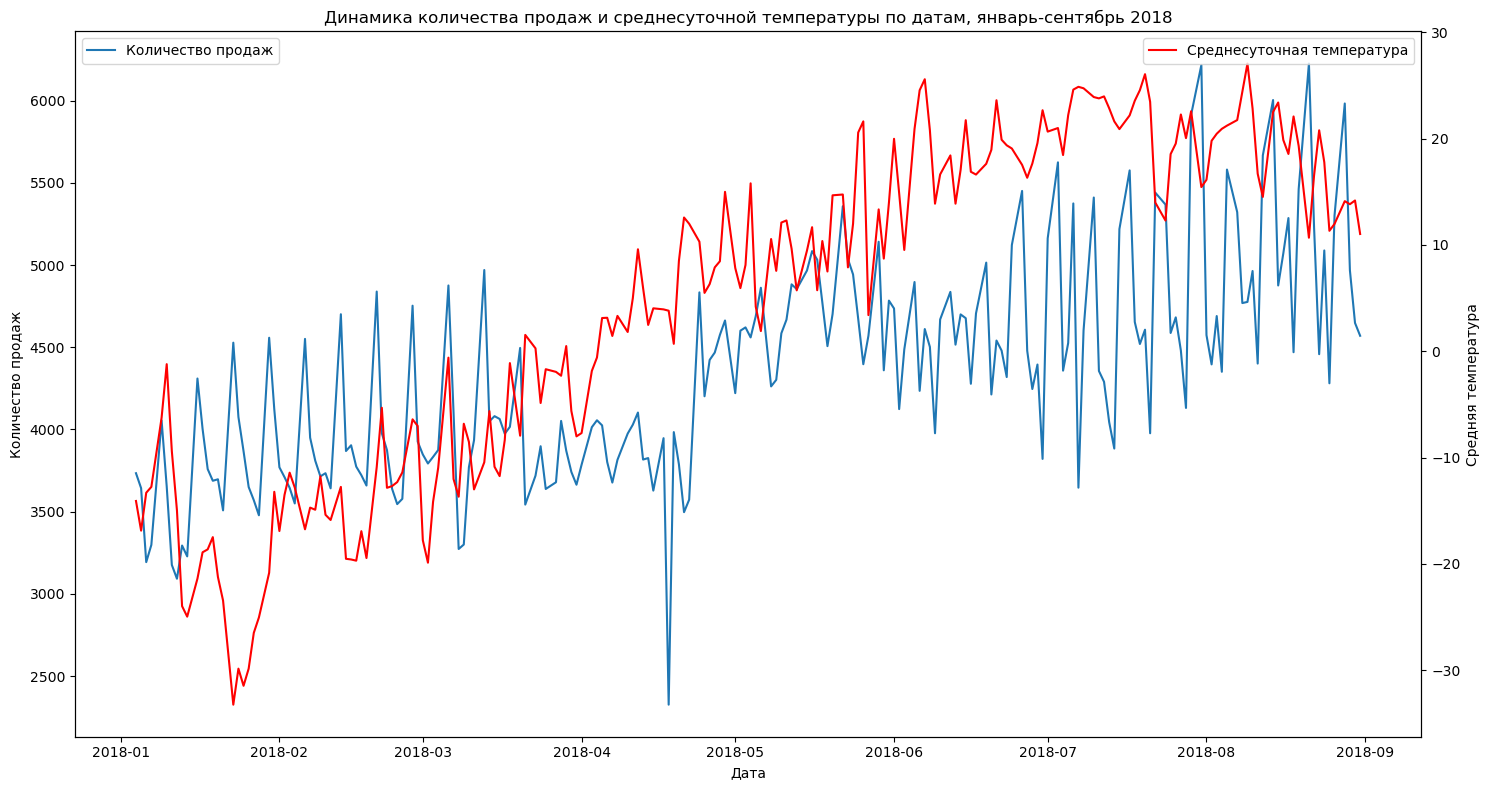

In [70]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='Дата', y='Количество продаж', data=sales_temperatures, label='Количество продаж')
plt.legend(loc='upper left')
plt.ylabel('Количество продаж')
ax2 = plt.twinx()
sns.lineplot(x='Дата', y='Temperature', data=sales_temperatures, color='red', label='Среднесуточная температура')
plt.title('Динамика количества продаж и среднесуточной температуры по датам, январь-сентябрь 2018')
ax2.set_ylabel('Средняя температура')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.legend()
plt.show()

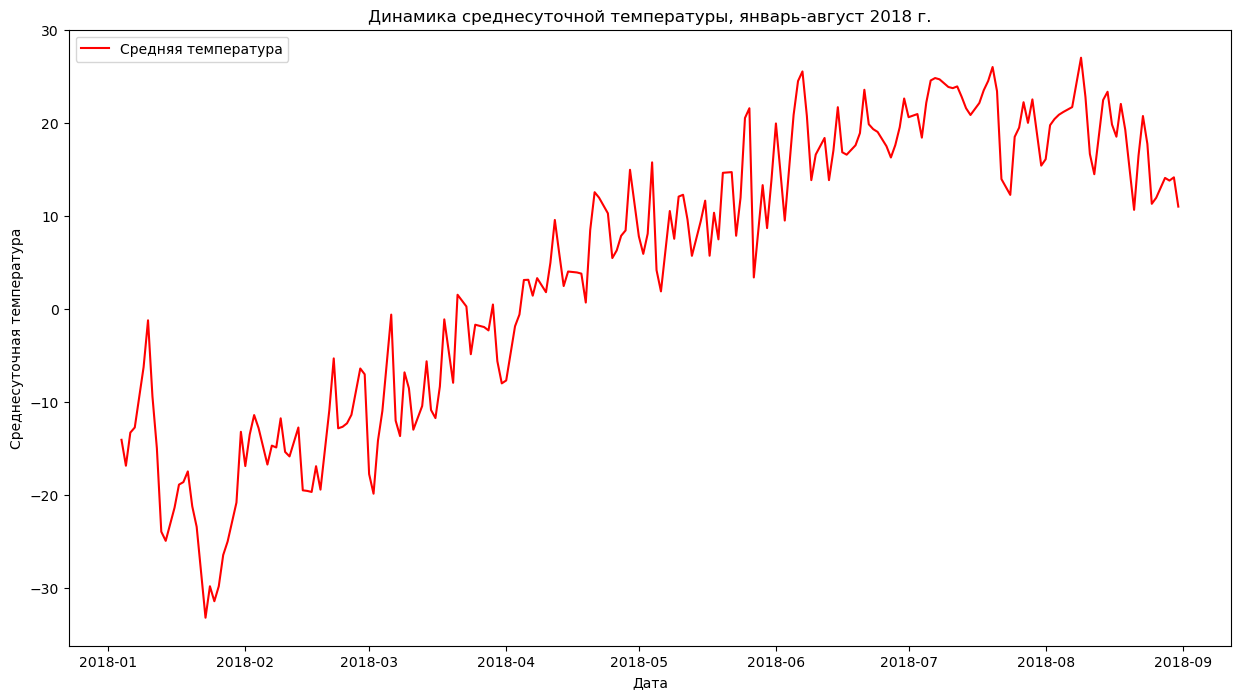

In [71]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='Дата', y='Temperature', data=sales_temperatures, label='Средняя температура', color='red')
plt.ylabel('Среднесуточная температура')
plt.title('Динамика среднесуточной температуры, январь-август 2018 г.')
plt.show()

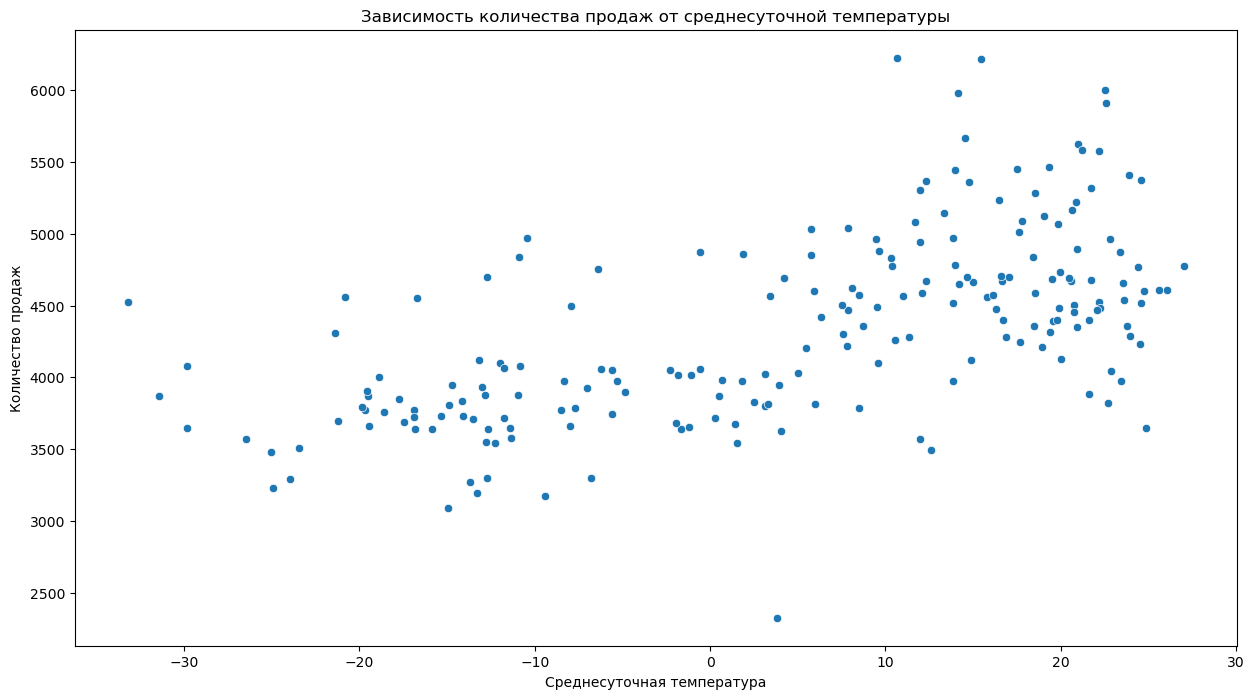

In [75]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='Temperature', y='Количество продаж', data=sales_temperatures)
plt.xlabel('Среднесуточная температура')
plt.title('Зависимость количества продаж от среднесуточной температуры')
plt.show()